<a href="https://colab.research.google.com/github/Jmontoyaor/SignalsandSystems-/blob/main/JUAN_FERNANDO_MONTOYA_ORTIZ___EJERCICIO_reconstruccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMAGEN PROCESO

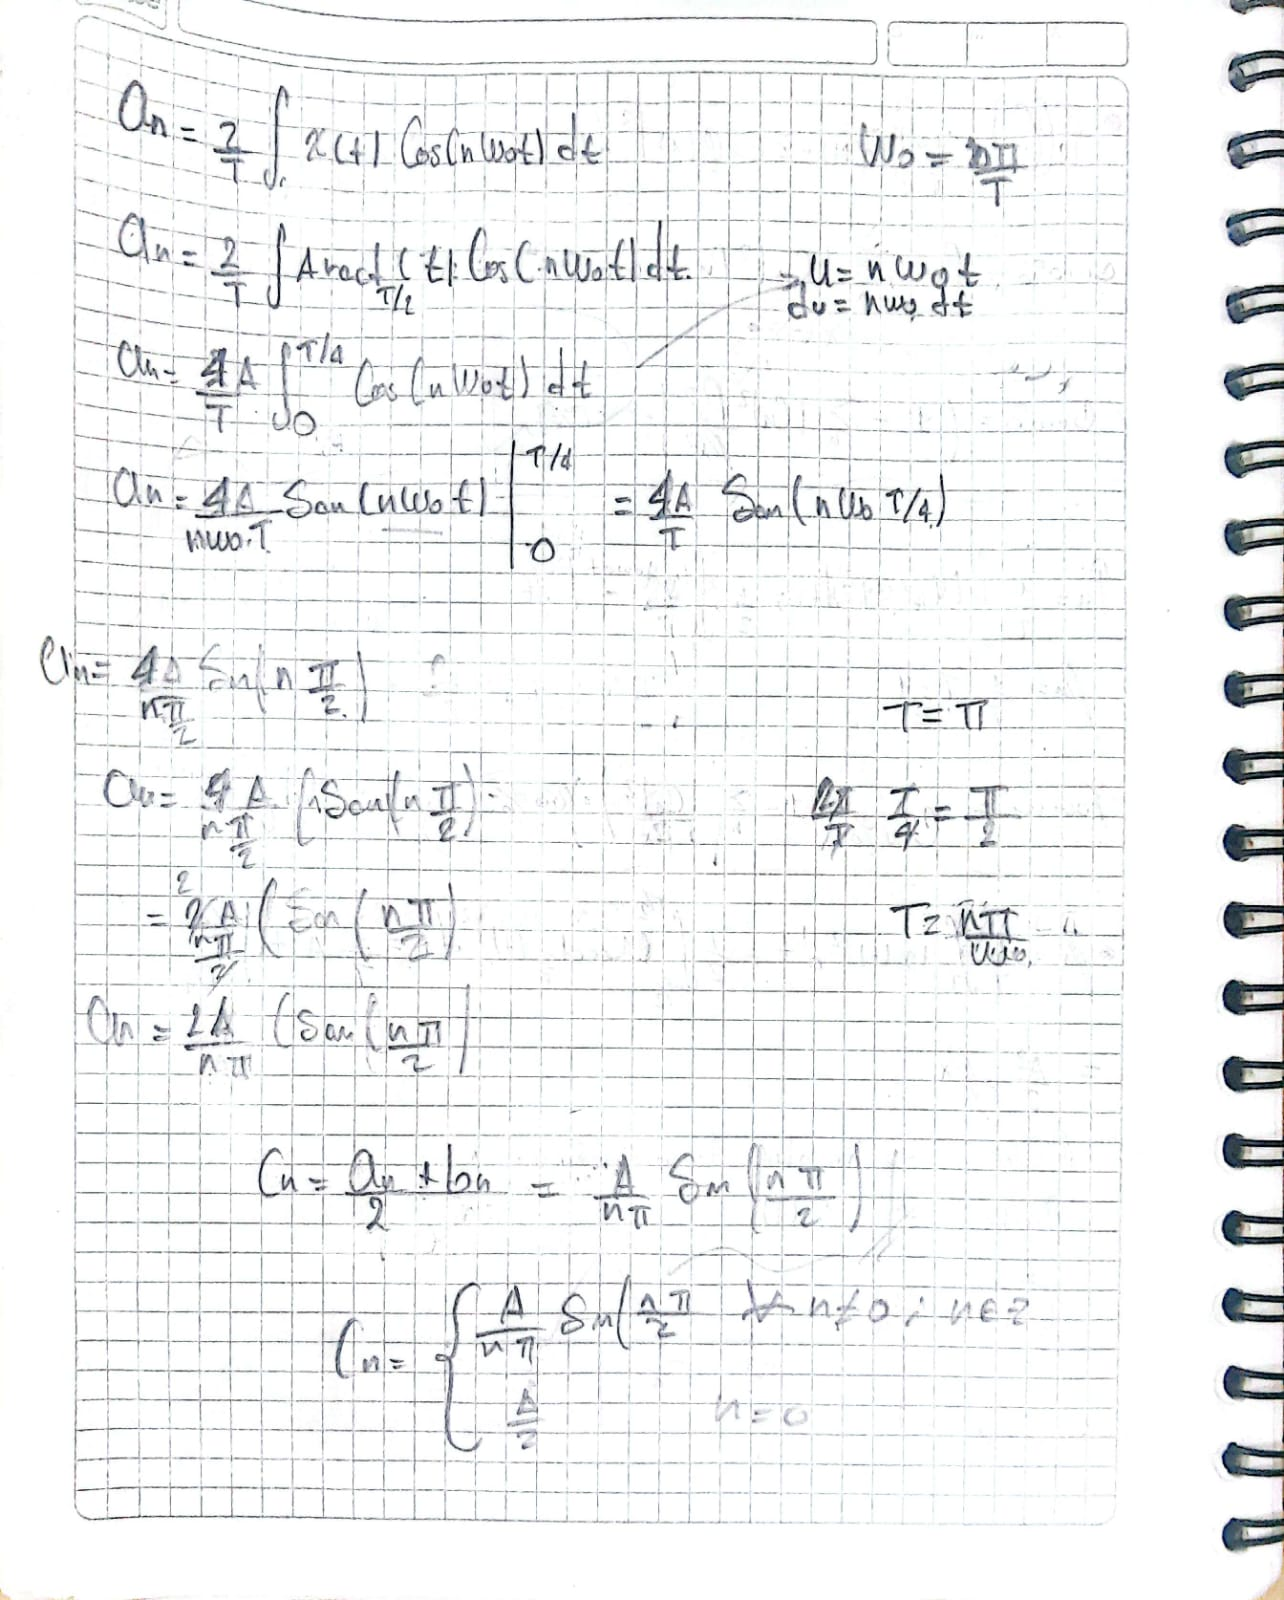


#Ejercicio 1

### Desarrollo de coeficientes de la serie de Fourier

$$
a_n = \frac{2}{T} \int_0^{T/2} x(t) \cos(n \omega_0 t)\, dt
$$

$$
a_n = \frac{2}{T} \int_0^{T/2} A \left(1 - \frac{2t}{T} \right) \cos(n \omega_0 t)\, dt
\quad \text{con } \omega_0 = \frac{2\pi}{T}
$$

Sustituyendo \( u = n\omega_0 t \Rightarrow du = n\omega_0 dt \):

$$
a_n = \frac{4A}{T} \int_0^{T/4} \cos(n \omega_0 t)\, dt
$$

$$
a_n = \frac{4A}{n \omega_0 T} \sin(n \omega_0 t) \bigg|_0^{T/4}
= \frac{4A}{T} \cdot \frac{\sin(n \omega_0 T / 4)}{n \omega_0}
$$

Como \( \omega_0 = \frac{2\pi}{T} \Rightarrow n \omega_0 T = 2\pi n \), entonces:

$$
a_n = \frac{4A}{n \pi} \sin\left( \frac{n\pi}{2} \right)
$$

$$
a_n = \frac{2A}{n \pi} \cdot \sin\left( \frac{n\pi}{2} \right)
$$

Coeficientes complejos:

$$
c_n = \frac{a_n}{2} = \frac{A}{n\pi} \sin\left( \frac{n\pi}{2} \right)
$$

Y:

$$
c_n = \begin{cases}
\frac{A}{n\pi} \sin\left( \frac{n\pi}{2} \right), & n \ne 0 \\
\frac{A}{2}, & n = 0
\end{cases}
$$


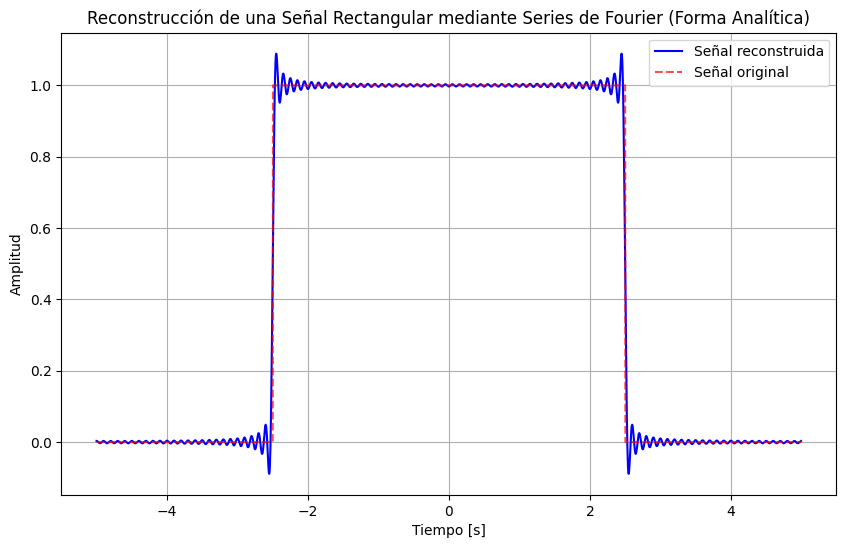

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Especificaciones de la señal rectangular
A = 1  # Amplitud de la señal
T = 5  # Ancho del pulso rectangular (duración)
Fs = 50 * T  # Frecuencia de muestreo definida
tv = np.arange(-T, T, 1/Fs) # Vector de tiempo generado
Nm = len(tv) # Numero de muestras requeridas

# Generar la señal rectangular
xo = np.zeros_like(tv)
xo[(tv >= -T/2) & (tv <= T/2)] = A

# Especificaciones de la Serie de Fourier
N = 100  # Numero de armónicos
wo = np.pi / T # Frecuencia fundamental

# Calcular los coeficientes de la Serie de Fourier analíticamente
ao = A / 2
an = np.zeros(N)
bn = np.zeros(N)

for n in range(1, N + 1):
    an[n-1] = (2 * A / (n * np.pi)) * np.sin(n * np.pi / 2)

# Inicializar la señal reconstruida con el término constante ao
xo_reconstructed = ao

# Recorrer los índices de la serie de Fourier y sumar los términos
for n in range(1, N + 1):
    xo_reconstructed += an[n-1] * np.cos(n * wo * tv) + bn[n-1] * np.sin(n * wo * tv)

# Gráfica de la señal
plt.figure(figsize=(10, 6))
plt.plot(tv, xo_reconstructed, label='Señal reconstruida', color='b')
plt.plot(tv, xo, label='Señal original', color='r', linestyle='dashed', alpha=0.7)
plt.title('Reconstrucción de una Señal Rectangular mediante Series de Fourier (Forma Analítica)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

#Imagen proceso

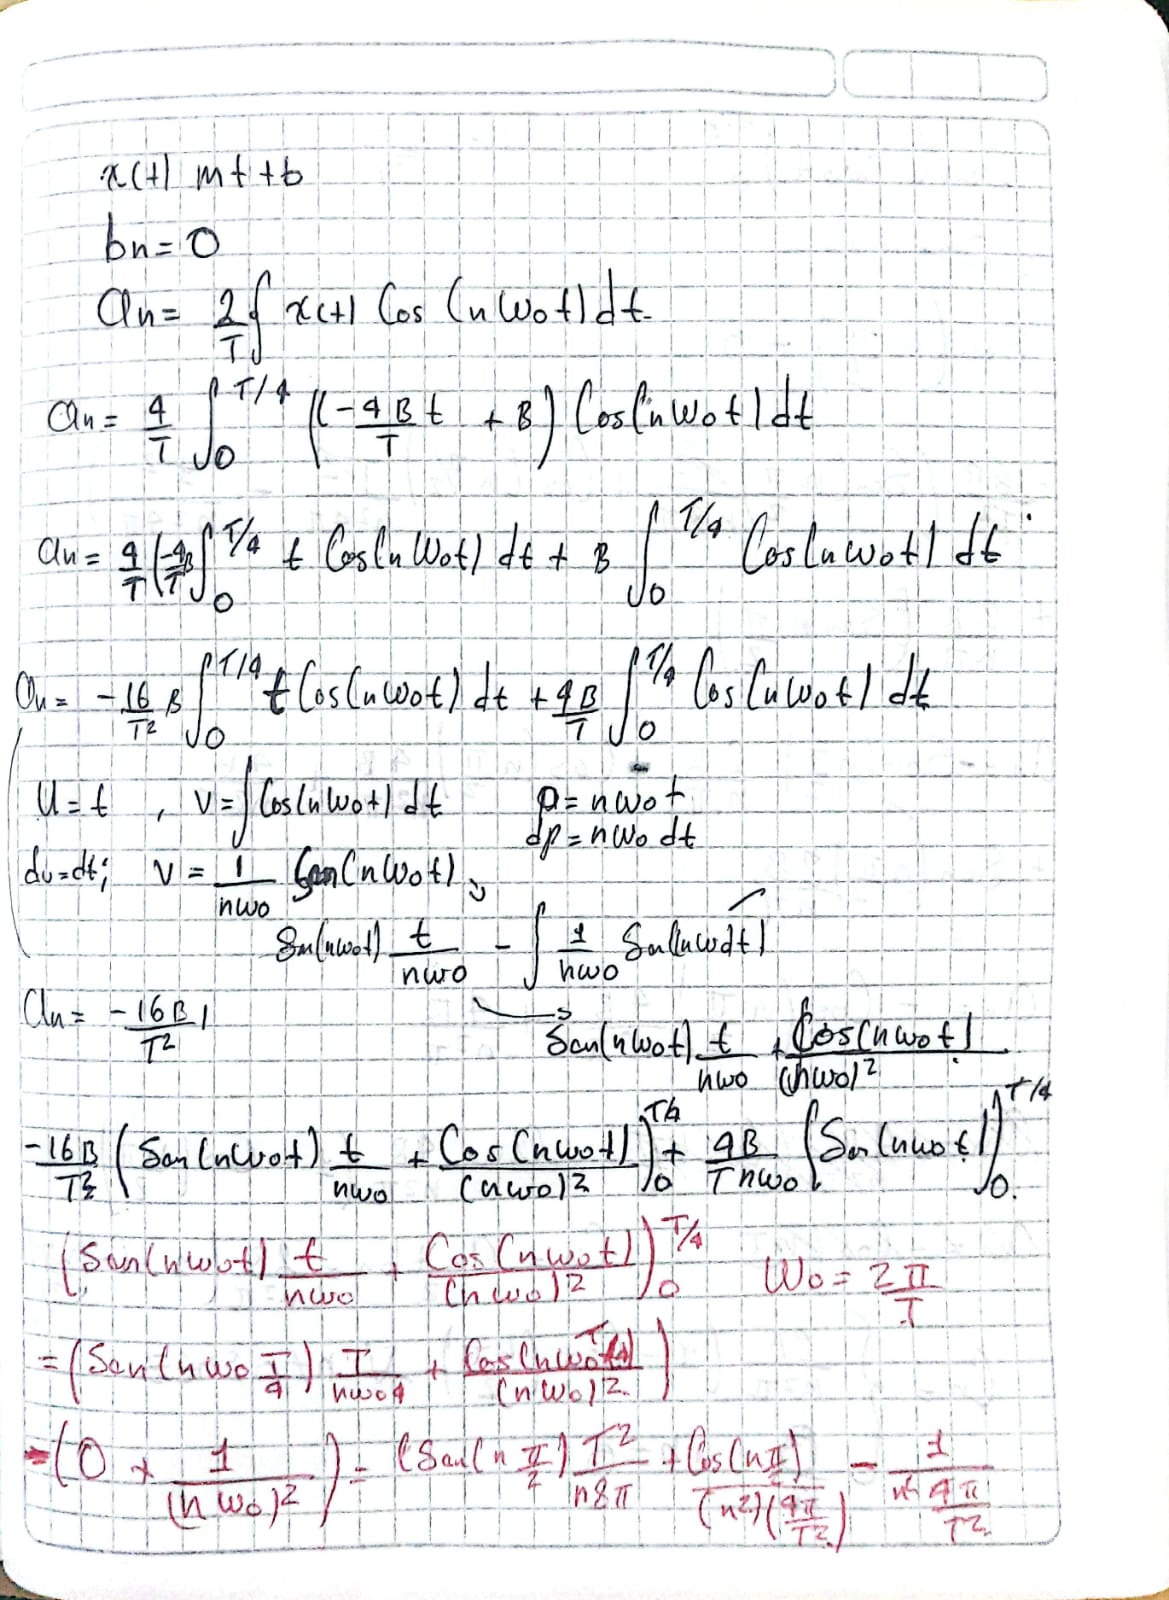

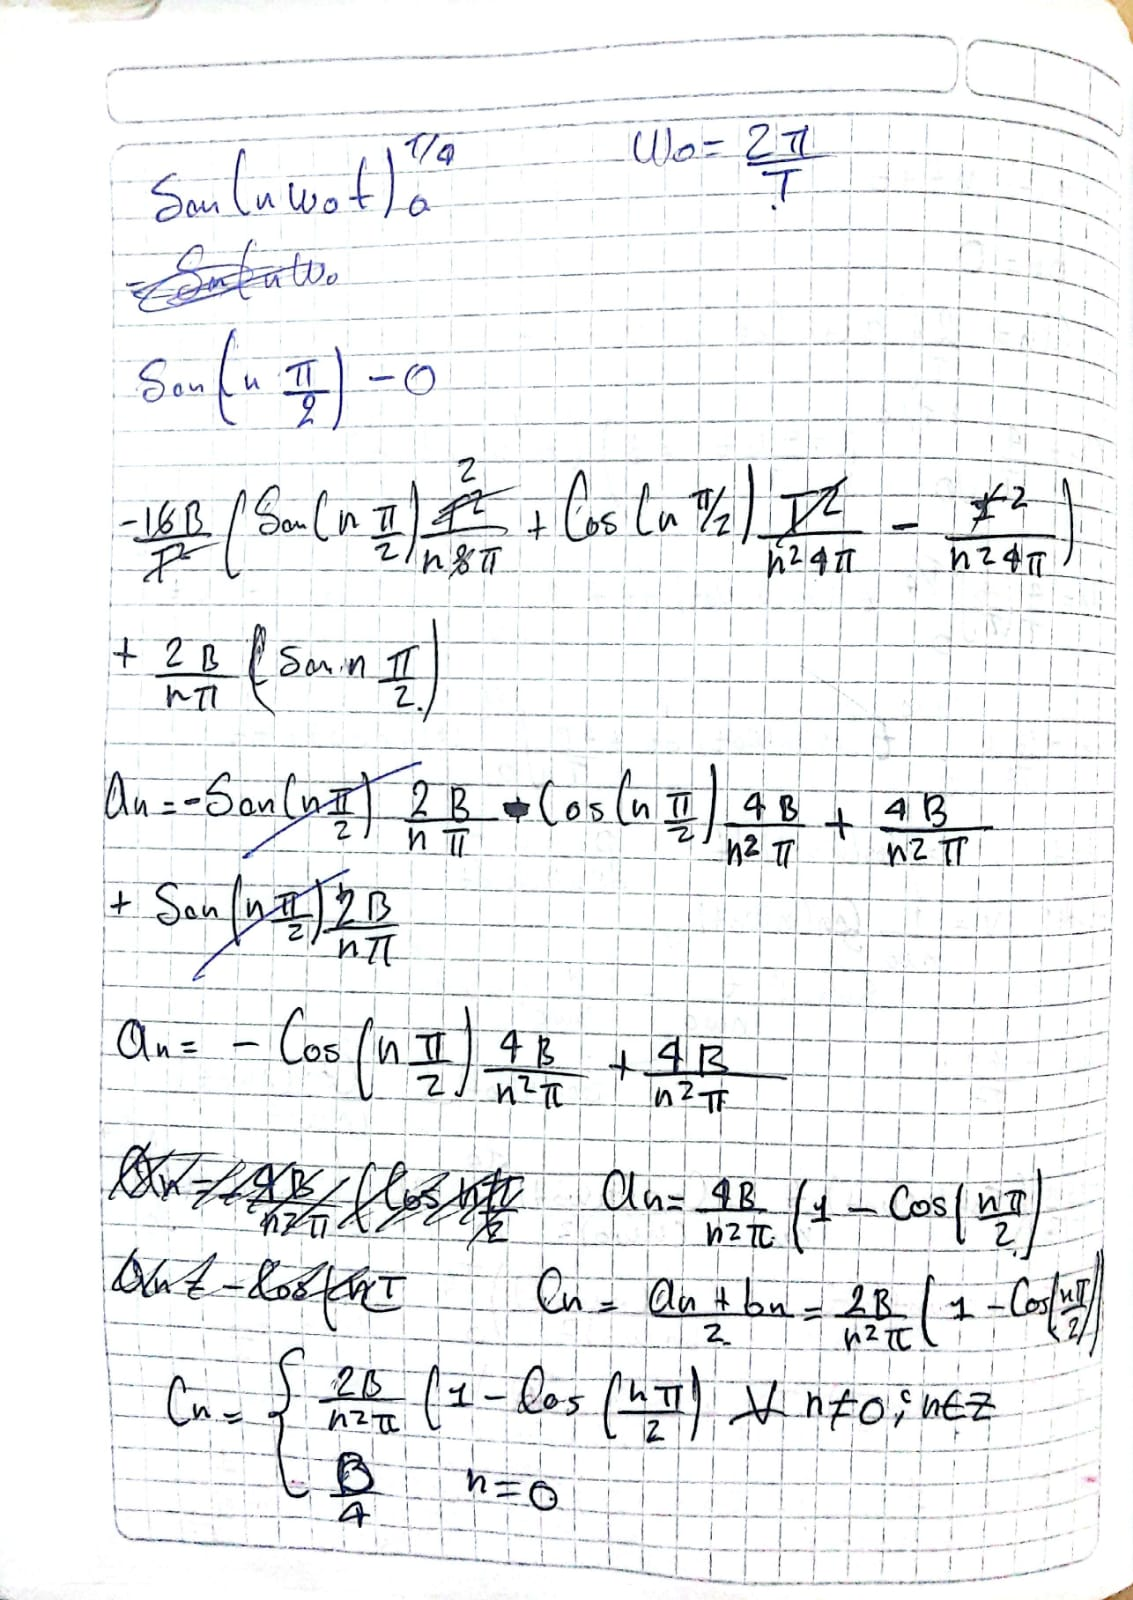

#Ejercicio 2

$$
x(t) = mt + b
$$

Sabemos que:
$$
b_n = 0
$$

El coeficiente \( a_n \) viene dado por:
$$
a_n = \frac{2}{T} \int_0^{T/4} x(t) \cos(n\omega_0 t)\, dt
$$

Dado que:
$$
x(t) = -\frac{4B}{T} t + B
$$

Entonces:
$$
a_n = \frac{4}{T} \int_0^{T/4} \left(-\frac{4B}{T}t + B\right) \cos(n\omega_0 t) \, dt
$$

Separando la integral:
$$
a_n = \frac{-16B}{T^2} \int_0^{T/4} t \cos(n\omega_0 t) \, dt + \frac{4B}{T} \int_0^{T/4} \cos(n\omega_0 t)\, dt
$$

Usamos integración por partes:

Sea
$$
u = t, \quad dv = \cos(n\omega_0 t)\, dt
$$

Entonces:
$$
du = dt, \quad v = \frac{\sin(n\omega_0 t)}{n\omega_0}
$$

Así que:
$$
\int t \cos(n\omega_0 t)\, dt = \frac{t \sin(n\omega_0 t)}{n\omega_0} - \int \frac{\sin(n\omega_0 t)}{n\omega_0}\, dt
= \frac{t \sin(n\omega_0 t)}{n\omega_0} + \frac{\cos(n\omega_0 t)}{(n\omega_0)^2}
$$

Entonces:
$$
a_n = \frac{-16B}{T^2} \left[ \frac{t \sin(n\omega_0 t)}{n\omega_0} + \frac{\cos(n\omega_0 t)}{(n\omega_0)^2} \right]_0^{T/4} + \frac{4B}{T} \left[ \frac{\sin(n\omega_0 t)}{n\omega_0} \right]_0^{T/4}
$$

Sustituimos \( \omega_0 = \frac{2\pi}{T} \):
$$
\omega_0 = \frac{2\pi}{T}, \quad n\omega_0 = \frac{2n\pi}{T}
$$

Y se tiene que:
$$
\sin\left(n \omega_0 \cdot \frac{T}{4} \right) = \sin\left(n \frac{\pi}{2} \right), \quad \cos\left(n \omega_0 \cdot \frac{T}{4} \right) = \cos\left(n \frac{\pi}{2} \right)
$$

Finalmente:
$$
a_n = -\frac{16B}{T^2} \left[ \frac{T}{4} \cdot \frac{\sin(n\frac{\pi}{2})}{n \cdot \frac{2\pi}{T}} + \frac{\cos(n\frac{\pi}{2})}{(n \cdot \frac{2\pi}{T})^2} \right] + \frac{4B}{T} \cdot \frac{\sin(n\frac{\pi}{2})}{n \cdot \frac{2\pi}{T}}
$$

Simplificando:
$$
a_n = -\cos\left(\frac{n\pi}{2}\right) \cdot \frac{4B}{n^2 \pi^2} + \frac{4B}{n^2 \pi^2}
$$

Entonces:
$$
a_n = \frac{4B}{n^2 \pi^2} \left(1 - \cos\left(\frac{n\pi}{2} \right)\right)
$$

Y como \( b_n = 0 \), el coeficiente complejo es:
$$
c_n = \frac{a_n + b_n}{2} = \frac{2B}{n^2 \pi^2} \left(1 - \cos\left( \frac{n\pi}{2} \right)\right), \quad \text{para } n \neq 0
$$

Y el coeficiente DC es:
$$
c_0 = \frac{B}{4}
$$

Por lo tanto:
$$
c_n =
\begin{cases}
\frac{2B}{n^2 \pi^2} \left(1 - \cos\left( \frac{n\pi}{2} \right) \right), & n \in \mathbb{Z},\, n \neq 0 \\
\frac{B}{4}, & n = 0
\end{cases}
$$


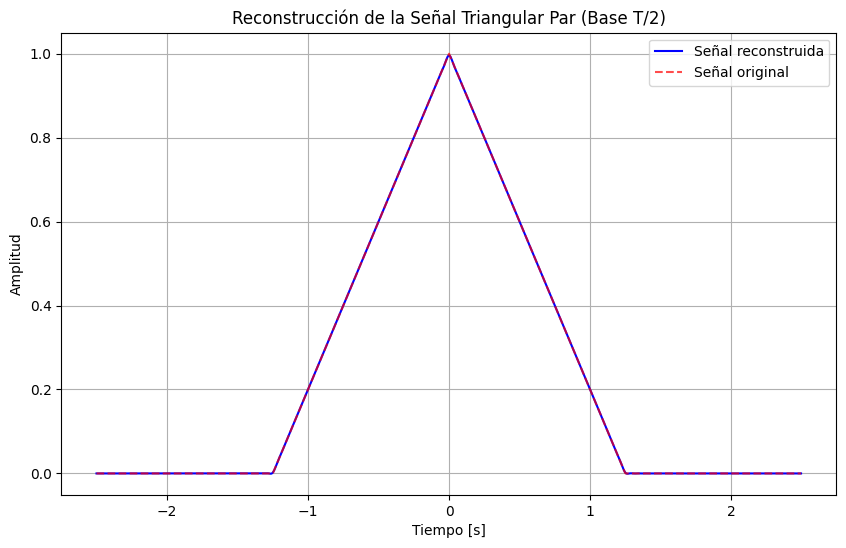

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Especificaciones de la señal
B = 1
T = 5
Fs = 50 * T
tv = np.arange(-T/2, T/2, 1/Fs)
wo = 2 * np.pi / T
N = 100

# Generar la señal original (pulso triangular par, base T/2)
xo = np.zeros_like(tv)
for i, t in enumerate(tv):
    if -T/4 <= t <= 0:
        xo[i] = (4 * B / T) * (t + T / 4)
    elif 0 < t <= T/4:
        xo[i] = (-4 * B / T) * (t - T / 4)

# Coeficiente DC
ao = B / 2

# Calcular coeficientes an
an = np.zeros(N)
for n in range(1, N + 1):
    an[n-1] = (-4 * B / (n**2 * np.pi**2)) * (np.cos(n * np.pi / 2) - 1)

# Inicializar la señal reconstruida
xo_reconstructed = ao / 2

# Sumar los términos de la Serie de Fourier
for n in range(N):
    xo_reconstructed += an[n] * np.cos((n + 1) * wo * tv)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(tv, xo_reconstructed, label='Señal reconstruida', color='b')
plt.plot(tv, xo, label='Señal original', color='r', linestyle='dashed', alpha=0.7)
plt.title('Reconstrucción de la Señal Triangular Par (Base T/2)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

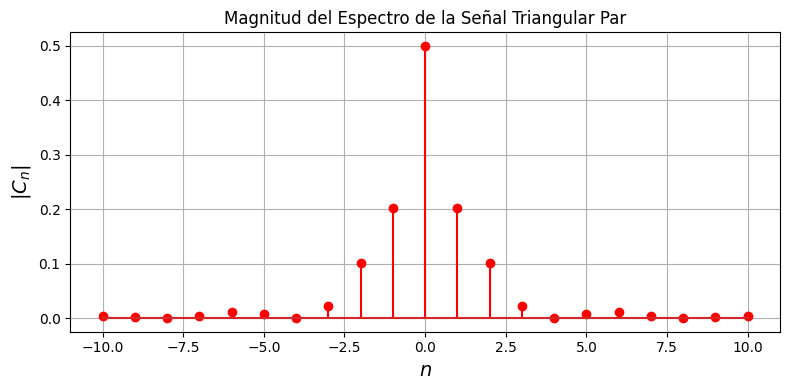

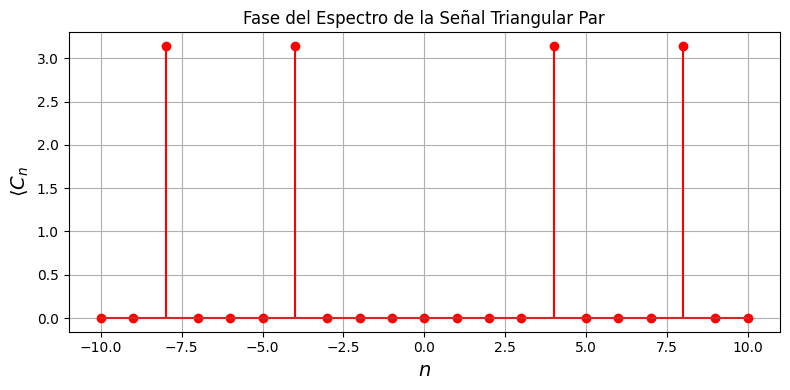

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Especificaciones de la señal
B = 1
T = 5
Fs = 50 * T
nv = np.arange(-T/2, T/2, 1/Fs)
wo = 2 * np.pi / T
N = 10
# Vector de números armónicos (incluyendo el 0)
nv = np.arange(-N, N + 1)



# Calcular los coeficientes Cn para la señal triangular par
Cn = np.zeros(len(nv), dtype=complex)
Cn[np.where(nv == 0)[0][0]] = B / 2
for i, n_val in enumerate(nv):
    if n_val != 0:
        an = (-4 * B / (n_val**2 * np.pi**2)) * (np.cos(n_val * np.pi / 2) - 1)
        Cn[i] = an / 2

# Graficar la magnitud del espectro
plt.figure(figsize=(8, 4))
plt.stem(nv, np.abs(Cn), 'r')
plt.xlabel(r'$n$', fontsize=14)
plt.ylabel(r'$|C_n|$', fontsize=14)
plt.title('Magnitud del Espectro de la Señal Triangular Par')
plt.axis('tight')
plt.grid(True)
plt.tight_layout()
plt.show()

# Graficar la fase del espectro
plt.figure(figsize=(8, 4))
plt.stem(nv, np.angle(Cn), 'r')
plt.xlabel(r'$n$', fontsize=14)
plt.ylabel(r'$\langle C_n$', fontsize=14)
plt.title('Fase del Espectro de la Señal Triangular Par')
plt.axis('tight')
plt.grid(True)
plt.tight_layout()
plt.show()